#### Load data & libraries

In [34]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql.types import IntegerType

In [35]:
pd.options.display.max_rows = None
pd.options.display.max_columns = None

In [ ]:
# 1. Khởi tạo cấu hình kết nối SparkSession
spark = SparkSession.builder \
    .appName("EDA_raw") \
    .master("local[*]") \
    .getOrCreate()

In [ ]:
# 2. Đọc dữ liệu trực tiếp từ HDFS
hdfs_input_path = "hdfs://localhost:9000/big_data/hotel_bookings.csv"
df = spark.read.csv(hdfs_input_path, header=True, inferSchema=True)

In [37]:
df.printSchema()

root
 |-- hotel: string (nullable = true)
 |-- is_canceled: integer (nullable = true)
 |-- lead_time: integer (nullable = true)
 |-- arrival_date_year: integer (nullable = true)
 |-- arrival_date_month: string (nullable = true)
 |-- arrival_date_week_number: integer (nullable = true)
 |-- arrival_date_day_of_month: integer (nullable = true)
 |-- stays_in_weekend_nights: integer (nullable = true)
 |-- stays_in_week_nights: integer (nullable = true)
 |-- adults: integer (nullable = true)
 |-- children: string (nullable = true)
 |-- babies: integer (nullable = true)
 |-- meal: string (nullable = true)
 |-- country: string (nullable = true)
 |-- market_segment: string (nullable = true)
 |-- distribution_channel: string (nullable = true)
 |-- is_repeated_guest: integer (nullable = true)
 |-- previous_cancellations: integer (nullable = true)
 |-- previous_bookings_not_canceled: integer (nullable = true)
 |-- reserved_room_type: string (nullable = true)
 |-- assigned_room_type: string (nullab

In [38]:
df.show(5)

+------------+-----------+---------+-----------------+------------------+------------------------+-------------------------+-----------------------+--------------------+------+--------+------+----+-------+--------------+--------------------+-----------------+----------------------+------------------------------+------------------+------------------+---------------+------------+-----+-------+--------------------+-------------+----+---------------------------+-------------------------+------------------+-----------------------+
|       hotel|is_canceled|lead_time|arrival_date_year|arrival_date_month|arrival_date_week_number|arrival_date_day_of_month|stays_in_weekend_nights|stays_in_week_nights|adults|children|babies|meal|country|market_segment|distribution_channel|is_repeated_guest|previous_cancellations|previous_bookings_not_canceled|reserved_room_type|assigned_room_type|booking_changes|deposit_type|agent|company|days_in_waiting_list|customer_type| adr|required_car_parking_spaces|total_

In [39]:
df.columns

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

#### Type parsing

In [40]:
df.select("children").groupBy("children").count().show()

+--------+------+
|children| count|
+--------+------+
|       3|    76|
|       0|110796|
|       1|  4861|
|      10|     1|
|       2|  3652|
|      NA|     4|
+--------+------+



In [41]:
# Cần impute để plot ở các bước sau
df = df.withColumn(
    "children", 
    F.when((F.col("children") == "NA") | F.col("children").isNull(), "0").otherwise(F.col("children"))
).withColumn(
    "children", 
    F.col("children").cast(IntegerType())
)

df.select("children").distinct().show()

+--------+
|children|
+--------+
|       1|
|       3|
|      10|
|       2|
|       0|
+--------+



#### Duplicate records

In [42]:
print(f"Số lượng bản ghi: {df.count()}")
print(f"Số lượng bản ghi unique: {df.distinct().count()}")

Số lượng bản ghi: 119390
Số lượng bản ghi unique: 87396


In [43]:
# 1. Gom nhóm theo TOÀN BỘ các cột và đếm số lượng lặp lại
grouped_df = df.groupBy(df.columns).count()

# 2. Lọc các record thỏa mãn 3 điều kiện: 
# agent Null AND company Null AND bị duplicate (count > 1)
target_records = grouped_df.filter(
    (F.col("agent").isNull() | (F.col("agent") == "NULL") | (F.col("agent") == "NA")) & 
    (F.col("company").isNull() | (F.col("company") == "NULL") | (F.col("company") == "NA")) & 
    (F.col("count") > 1)
).orderBy(F.col("count").desc())

# 3. In
print(f"Tổng số NHÓM record không có agent và company: {target_records.count()}")

target_records.select(
    "count",                 # Số lần lặp lại y hệt nhau
    "hotel",                 # Xem thử City hay Resort hay bị lặp
    "market_segment",        # Quan trọng nhất: Có phải là Groups/Offline TA không?
    "distribution_channel",  # Có phải TA/TO không?
    "lead_time",             # Đặt trước bao nhiêu ngày?
    "adults",                # Quy mô nhóm khách
    "adr",                   # Giá phòng (nếu giá rất rẻ hoặc bằng 0 thường là nhóm/nội bộ)
    "reservation_status"     # Cả cục này bị Canceled hay Check-Out?
).show(20, truncate=False)

Tổng số NHÓM record không có agent và company: 573
+-----+------------+--------------+--------------------+---------+------+-----+------------------+
|count|hotel       |market_segment|distribution_channel|lead_time|adults|adr  |reservation_status|
+-----+------------+--------------+--------------------+---------+------+-----+------------------+
|180  |City Hotel  |Groups        |TA/TO               |277      |2     |100.0|Canceled          |
|99   |City Hotel  |Groups        |TA/TO               |28       |2     |95.0 |Canceled          |
|69   |City Hotel  |Offline TA/TO |TA/TO               |150      |1     |120.0|Canceled          |
|60   |City Hotel  |Groups        |TA/TO               |164      |1     |160.0|Canceled          |
|59   |City Hotel  |Groups        |TA/TO               |104      |1     |160.0|Canceled          |
|54   |City Hotel  |Groups        |Direct              |92       |2     |85.0 |Canceled          |
|49   |City Hotel  |Offline TA/TO |TA/TO               |10

#### Logic check

In [44]:
print(f"Tổng số dòng ban đầu: {df.count()}\n")
print("=== TỔNG HỢP CÁC LỖI LOGIC TRONG DỮ LIỆU ===")

# 1. Booking không có khách (adults + children + babies = 0)
no_guests = df.filter((F.col("adults") + F.col("children") + F.col("babies")) == 0)
print(f"1. Tổng khách = 0: {no_guests.count()} dòng")

# 2. 0 đêm & 0 đồng
zero_night_adr = df.filter(
    (F.col("stays_in_weekend_nights") + F.col("stays_in_week_nights") == 0) & 
    (F.col("adr") == 0)
)
print(f"2. 0 đêm lưu trú & 0đ: {zero_night_adr.count()} dòng")

# 3. Nghịch lý thời gian (Chờ lâu hơn Lead time)
invalid_waitlist = df.filter(F.col("days_in_waiting_list") > F.col("lead_time"))
print(f"3. Thời gian Waitlist > Lead time: {invalid_waitlist.count()} dòng")

# 4. Giá phòng âm
negative_adr = df.filter(F.col("adr") < 0)
print(f"4. Giá phòng (ADR) bị âm: {negative_adr.count()} dòng")

# 5. Xung đột trạng thái mục tiêu
status_conflict = df.filter(
    ((F.col("is_canceled") == 1) & (F.col("reservation_status") == "Check-Out")) |
    ((F.col("is_canceled") == 0) & F.col("reservation_status").isin("Canceled", "No-Show"))
)
print(f"5. Xung đột trạng thái Hủy/Không hủy: {status_conflict.count()} dòng")

# 6. Trẻ em/Em bé đi một mình (adults = 0 nhưng children > 0 hoặc babies > 0)
minors_alone = df.filter(
    (F.col("adults") == 0) & ((F.col("children") > 0) | (F.col("babies") > 0))
)
print(f"6. Trẻ em đi một mình: {minors_alone.count()} dòng")

# 7. Khách quen "ảo"
fake_repeated = df.filter(
    (F.col("is_repeated_guest") == 1) & 
    (F.col("previous_cancellations") == 0) & 
    (F.col("previous_bookings_not_canceled") == 0)
)
print(f"7. Đánh dấu Khách quen nhưng lịch sử = 0: {fake_repeated.count()} dòng")

Tổng số dòng ban đầu: 119390

=== TỔNG HỢP CÁC LỖI LOGIC TRONG DỮ LIỆU ===
1. Tổng khách = 0: 180 dòng
2. 0 đêm lưu trú & 0đ: 715 dòng
3. Thời gian Waitlist > Lead time: 0 dòng
4. Giá phòng (ADR) bị âm: 1 dòng
5. Xung đột trạng thái Hủy/Không hủy: 0 dòng
6. Trẻ em đi một mình: 223 dòng
7. Đánh dấu Khách quen nhưng lịch sử = 0: 590 dòng


#### Null imputation

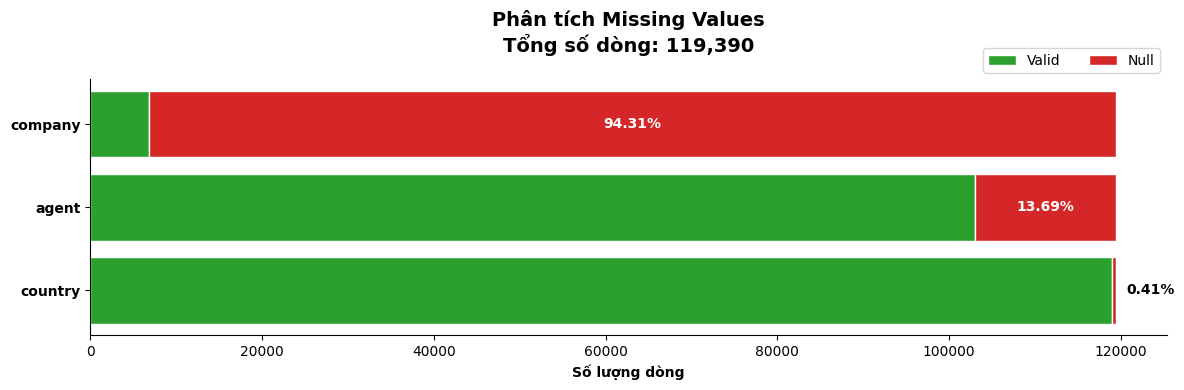

In [45]:
total_rows = df.count()

null_expressions = []
for col_name, col_type in df.dtypes:
    base_condition = (
        F.col(col_name).isNull() | 
        (F.col(col_name).cast("string") == "NULL") | 
        (F.col(col_name).cast("string") == "NA")
    )
    
    if col_type in ["double", "float"]:
        final_condition = base_condition | F.isnan(F.col(col_name))
    else:
        final_condition = base_condition
        
    null_expressions.append(F.count(F.when(final_condition, col_name)).alias(col_name))

null_counts_row = df.select(null_expressions).collect()[0]
null_dict = null_counts_row.asDict()

# Lọc ra những cột có lượng Null > 0 và sắp xếp giảm dần
cols_with_null = {k: v for k, v in null_dict.items() if v > 0}
sorted_cols = sorted(cols_with_null.items(), key=lambda item: item[1], reverse=True)

columns = [item[0] for item in sorted_cols]
null_values = [item[1] for item in sorted_cols]
valid_values = [total_rows - n for n in null_values]
null_ratios = [(n / total_rows) * 100 for n in null_values]

# Tự động điều chỉnh chiều cao biểu đồ dựa trên số lượng cột bị Null
fig, ax = plt.subplots(figsize=(12, max(4, len(columns) * 0.8)))

y_pos = np.arange(len(columns))

# Vẽ thanh màu xanh lá (Dữ liệu hợp lệ)
ax.barh(y_pos, valid_values, color='#2ca02c', edgecolor='white', label='Valid')

# Vẽ thanh màu đỏ (Dữ liệu Null) nối tiếp phía sau
ax.barh(y_pos, null_values, left=valid_values, color='#d62728', edgecolor='white', label='Null')

# Ghi chú (Annotation) tỷ lệ % lên biểu đồ
for i in range(len(columns)):
    # Tọa độ X nằm ngay giữa khoảng đỏ: valid + (null / 2)
    text_x = valid_values[i] + (null_values[i] / 2)
    
    # Mẹo UI: Nếu tỷ lệ Null quá nhỏ (< 2%), vạch đỏ sẽ rất mỏng.
    # Ta dời chữ ra ngoài vạch đỏ một chút và đổi thành màu đen để không bị đè nát.
    if null_ratios[i] < 2.0:
        ax.text(total_rows + (total_rows * 0.01), y_pos[i], 
                f"{null_ratios[i]:.2f}%", color='black', va='center', fontweight='bold')
    else:
        # Nếu vạch đỏ đủ rộng, in số màu trắng ngay giữa
        ax.text(text_x, y_pos[i], f"{null_ratios[i]:.2f}%", 
                color='white', va='center', ha='center', fontweight='bold')

# Tùy chỉnh giao diện (Format)
ax.set_yticks(y_pos)
ax.set_yticklabels(columns, fontweight='bold', fontsize=10)
ax.set_xlabel('Số lượng dòng', fontweight='bold')
ax.set_title(f'Phân tích Missing Values\nTổng số dòng: {total_rows:,}', 
             pad=20, fontsize=14, fontweight='bold')

# Đảo ngược trục Y để cột lỗi nặng nhất (nhiều Null nhất) nằm trên cùng
ax.invert_yaxis()

# Đặt chú thích (Legend) xuống dưới cùng
ax.legend(loc='upper right', bbox_to_anchor=(1, 1.15), ncol=2)

# Xóa viền trên và viền phải cho biểu đồ thanh thoát hơn
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Outlier

In [46]:
df.select(
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests').summary().show()

+-------+-------------------+------------------+------------------+------------------+------------------------+-----------------------+--------------------+------------------+-------------------+--------------------+---------+-------------------+----------------------+------------------------------+-------------------+--------------------+------------------+---------------------------+-------------------------+
|summary|        is_canceled|         lead_time| arrival_date_year|arrival_date_month|arrival_date_week_number|stays_in_weekend_nights|stays_in_week_nights|            adults|           children|              babies|     meal|  is_repeated_guest|previous_cancellations|previous_bookings_not_canceled|    booking_changes|days_in_waiting_list|               adr|required_car_parking_spaces|total_of_special_requests|
+-------+-------------------+------------------+------------------+------------------+------------------------+-----------------------+--------------------+--------------

In [48]:
outlier_cols = ["adr", "adults", "children", "babies"]

iqr_bounds = {}

print("=== BẢNG TÍNH TOÁN NGƯỠNG IQR TỰ ĐỘNG ===")
for col in outlier_cols:
    # Tính Q1 (25%) và Q3 (75%) với sai số 0.01 (Tối ưu cho Big Data)
    quantiles = df.approxQuantile(col, [0.25, 0.75], 0.01)
    q1 = quantiles[0]
    q3 = quantiles[1]
    iqr = round(q3 - q1, 4)
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    iqr_bounds[col] = {"lower": lower_bound, "upper": upper_bound}
    
    print(f"Cột [{col.upper()}]:")
    print(f"  - Q1: {q1} | Q3: {q3} | IQR: {iqr}")
    print(f"  - Giới hạn bình thường: Từ {lower_bound} đến {upper_bound}\n")

=== BẢNG TÍNH TOÁN NGƯỠNG IQR TỰ ĐỘNG ===
Cột [ADR]:
  - Q1: 68.85 | Q3: 125.0 | IQR: 56.15
  - Giới hạn bình thường: Từ -15.375 đến 209.225

Cột [ADULTS]:
  - Q1: 2.0 | Q3: 2.0 | IQR: 0.0
  - Giới hạn bình thường: Từ 2.0 đến 2.0

Cột [CHILDREN]:
  - Q1: 0.0 | Q3: 0.0 | IQR: 0.0
  - Giới hạn bình thường: Từ 0.0 đến 0.0

Cột [BABIES]:
  - Q1: 0.0 | Q3: 0.0 | IQR: 0.0
  - Giới hạn bình thường: Từ 0.0 đến 0.0



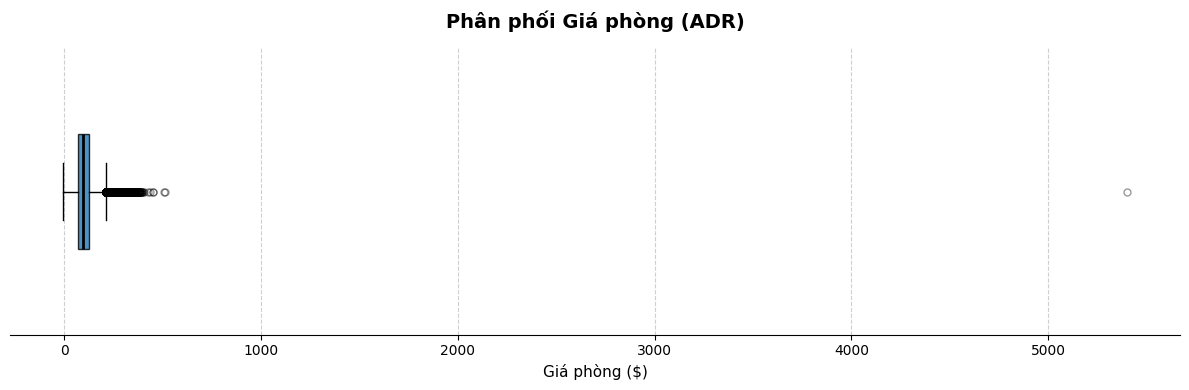

In [49]:
boxplot_adr = df.select('adr').na.drop().toPandas()

fig, ax = plt.subplots(figsize=(12, 4))

box = ax.boxplot(boxplot_adr['adr'], vert=False, patch_artist=True, widths=0.4,
                 flierprops=dict(marker='o', color='red', alpha=0.4, markersize=5))

# Tùy chỉnh màu sắc
for patch in box['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.8)
for median in box['medians']:
    median.set(color='black', linewidth=2)
    
ax.set_title('Phân phối Giá phòng (ADR)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Giá phòng ($)', fontsize=11)
ax.set_yticks([]) 
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

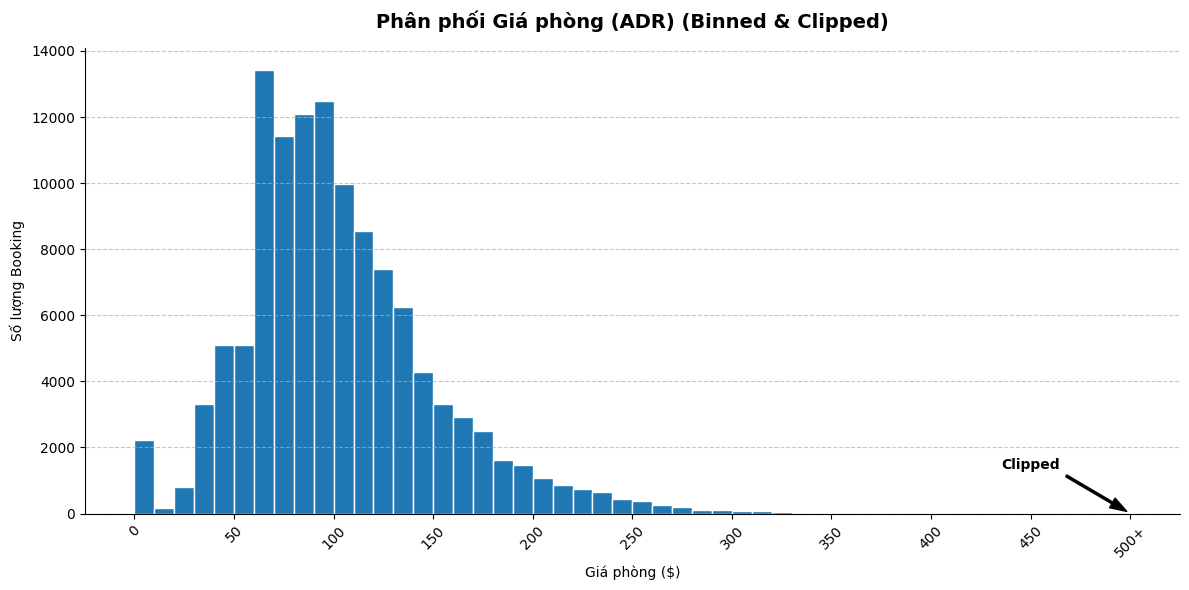

In [51]:
hist_adr = df.select("adr").na.drop().toPandas()

# GOM NHÓM outliers bằng CLIPPING: Ép mọi giá trị > 500 về thành 500. Các giá trị < 0 ép về 0.
CLIP_MAX = 500
hist_adr['adr_clipped'] = hist_adr['adr'].clip(lower=0, upper=CLIP_MAX)

fig, ax = plt.subplots(figsize=(12, 6))

# Vẽ Histogram với 50 bins
n, bins, patches = ax.hist(hist_adr['adr_clipped'], bins=50, color='#1f77b4', edgecolor='white')

# Làm nổi bật Bin cuối cùng (Chứa các Outliers đã được gom nhóm)
patches[-1].set_facecolor('#d62728') # Đổi màu cột cuối thành đỏ

# Tùy chỉnh giao diện
ax.set_title('Phân phối Giá phòng (ADR) (Binned & Clipped)', pad=15, fontsize=14, fontweight='bold')
ax.set_xlabel('Giá phòng ($)')
ax.set_ylabel('Số lượng Booking')

# Cấu hình trục X để hiển thị rõ việc gom nhóm
xticks = list(np.arange(0, CLIP_MAX, 50)) + [CLIP_MAX]
xticklabels = [str(x) for x in np.arange(0, CLIP_MAX, 50)] + [f"{CLIP_MAX}+"]
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=45)

# Thêm lưới mờ phía sau để dễ đọc số
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ghi chú (Annotation) chỉ thẳng vào cột Outlier
ax.annotate('Clipped', 
            xy=(CLIP_MAX, n[-1]), xytext=(CLIP_MAX - 50, n[-1] + (n.max()*0.1)),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [52]:
# Hàm vẽ biểu đồ cột rời rạc với Log Scale và Annotation
def plot_individual_discrete_bar(pdf_data, col_name, color, title):
    # Mỗi lần gọi hàm sẽ tạo một canvas hoàn toàn mới
    fig, ax = plt.subplots(figsize=(10, 5))
    
    x_labels = pdf_data[col_name].astype(int).astype(str)
    counts = pdf_data['count']
    
    bars = ax.bar(x_labels, counts, color=color, edgecolor='black', alpha=0.8)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Số lượng Booking (Log Scale)', fontsize=11)
    ax.set_xlabel(f'Số lượng', fontsize=11)
    
    # Bật Log Scale
    ax.set_yscale('log')
    
    # Ghi chú (Annotation) số lượng lên đỉnh cột
    for bar in bars:
        yval = bar.get_height()
        if yval > 0:
            ax.text(bar.get_x() + bar.get_width()/2, yval * 1.1, f'{int(yval):,}', 
                    ha='center', va='bottom', fontsize=10)#, fontweight='bold')

    # Làm gọn giao diện
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

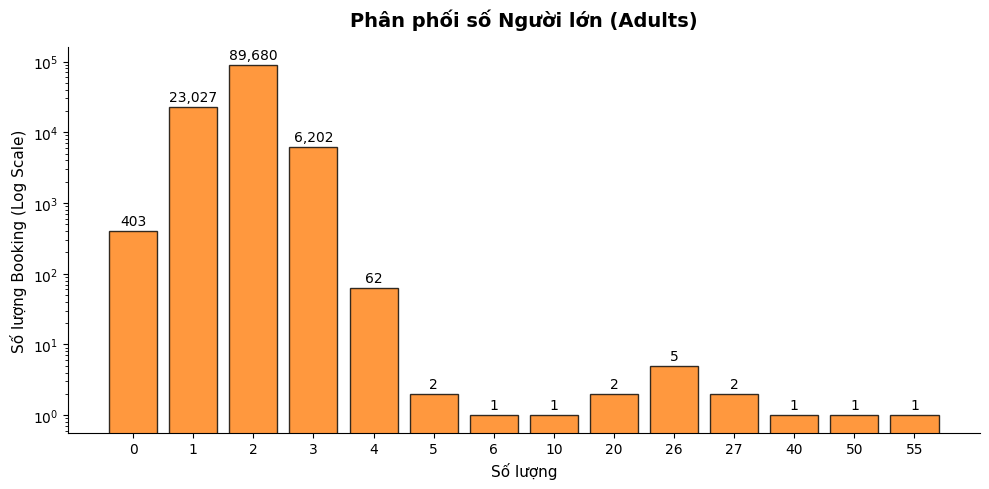

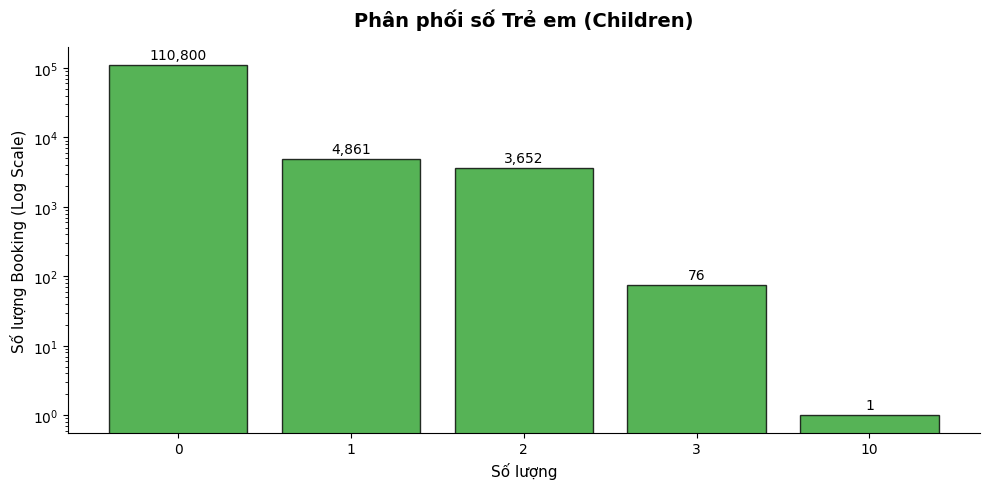

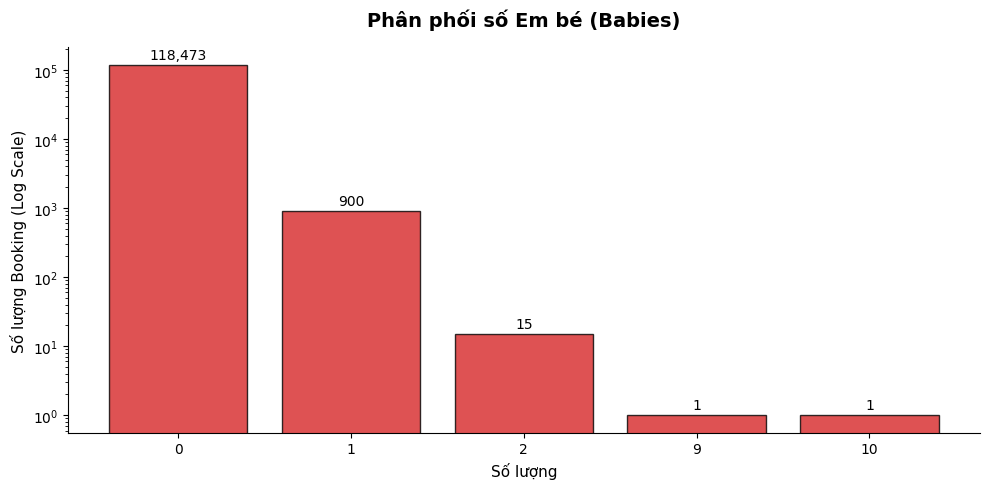

In [53]:

pdf_adults = df.groupBy('adults').count().orderBy('adults').toPandas()
pdf_children = df.groupBy('children').count().orderBy('children').toPandas()
pdf_babies = df.groupBy('babies').count().orderBy('babies').toPandas()

# Vẽ biểu đồ cho cột rời rạc Adults
plot_individual_discrete_bar(pdf_adults, 'adults', '#ff7f0e', 'Phân phối số Người lớn (Adults)')

# Vẽ biểu đồ cho cột rời rạc Children
plot_individual_discrete_bar(pdf_children, 'children', '#2ca02c', 'Phân phối số Trẻ em (Children)')

# Vẽ biểu đồ cho cột rời rạc Babies
plot_individual_discrete_bar(pdf_babies, 'babies', '#d62728', 'Phân phối số Em bé (Babies)')